In [7]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
from sklearn.model_selection import train_test_split

from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer, DropoutLayer, BatchNormalizationLayer
from src.models_numpy.dnn.activation import ReLUActivation, LeakyReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.metrics import accuracy
from src.models_numpy.dnn.dataset import Dataset
from src.data_processing import clean_text
from src.vectorizer import create_vectorizer
from src.models_numpy.dnn.optimizer import AdamOptimizer, SGDOptimizer

## Preprocessamento
Aplicamos a função `clean_text` com NLTK e dividimos em treino/validação (80/20).

In [9]:
df = pd.read_csv("../data/processed/dataset_combined.csv", sep=";")

label_map = {label: i for i, label in enumerate(sorted(df['Label'].unique()))}
df['label_id'] = df['Label'].map(label_map)

df['text_clean'] = df['Text'].apply(clean_text)

X_train, X_val, y_train, y_val = train_test_split(
    df[['Text', 'text_clean']], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

num_classes = len(label_map)
y_train_oh = np.eye(num_classes)[y_train.values]
y_val_oh = np.eye(num_classes)[y_val.values]

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Número de classes: {num_classes}")

Treino: 8000 amostras
Validação: 2000 amostras
Número de classes: 5


## Espaço de Parâmetros para Random Search
- Loss functions (CategoricalCrossEntropy, FocalLossMulticlass)
- Activation functions (ReLU, Sigmoid)

In [10]:
param_grid = {
    'loss_function': [('CategoricalCrossEntropy', CategoricalCrossEntropy)],
    'activation_function': [('LeakyReLU', LeakyReLUActivation)],
    'vectorizer_type': ['stylometric'],
    'char_ngram_range': [(2, 3), (2, 4)],
    'max_words': [5000, 10000, 15000],
    'hidden_neurons': [[256, 128], [512, 256], [256, 128, 64]],
    'learning_rate': [0.01, 0.005],
    'optimizer_type': ['adam'],
    'epochs': [150],
    'batch_size': [128, 256],
    'dropout_rate': [0.3, 0.2],
    'weight_decay': [0.0001],
    'use_batchnorm': [False, True],
    'patience': [15],
}

print(f"Tamanho do grid: {len(param_grid)} parâmetros")
print(f"Combinações totais teóricas: {np.prod([len(v) for v in param_grid.values()])}")

Tamanho do grid: 14 parâmetros
Combinações totais teóricas: 288


In [11]:
def train_with_params(params, X_train, y_train, X_val, y_val, num_classes):
    vectorizer = create_vectorizer(
        params['vectorizer_type'],
        max_words=params['max_words'],
        ngram_range=params.get('char_ngram_range', (2, 3))
    )

    X_tr = vectorizer.fit_transform(
        list(X_train['text_clean']),
        list(X_train['Text'])
    )
    X_te = vectorizer.transform(
        list(X_val['text_clean']),
        list(X_val['Text'])
    )
        
    if params.get('optimizer_type', 'adam') == 'adam':
        opt = AdamOptimizer(learning_rate=params['learning_rate'])
    else:
        opt = SGDOptimizer(learning_rate=params['learning_rate'], momentum=0.9)
        
    model = NeuralNetwork(
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        optimizer=opt,
        loss=params['loss_function'][1],
        metric=accuracy,
        early_stopping=True,
        patience=params.get('patience', 15),
        verbose=False,
    )
    
    input_dim = X_tr.shape[1]
    hidden_layers = params['hidden_neurons']
    
    model.add(DenseLayer(n_units=hidden_layers[0], input_shape=(input_dim,), 
                         l2_reg=params['weight_decay']))
    if params.get('use_batchnorm', False):
        model.add(BatchNormalizationLayer())
    model.add(params['activation_function'][1]())
    if params['dropout_rate'] > 0:
        model.add(DropoutLayer(rate=params['dropout_rate']))
    
    for i, units in enumerate(hidden_layers[1:]):
        model.add(DenseLayer(n_units=units, l2_reg=params['weight_decay']))
        if params.get('use_batchnorm', False):
            model.add(BatchNormalizationLayer())
        model.add(params['activation_function'][1]())
        if params['dropout_rate'] > 0:
            model.add(DropoutLayer(rate=params['dropout_rate'] / (i+2)))
    
    model.add(DenseLayer(n_units=num_classes, l2_reg=params['weight_decay']))
    model.add(SoftmaxActivation())
    
    dataset = Dataset(X_tr, y_train)
    val_dataset = Dataset(X_te, y_val)
    
    start_time = time.time()
    history = model.fit(dataset, val_dataset=val_dataset)
    training_time = time.time() - start_time
    
    if hasattr(model, 'best_epoch') and model.best_epoch is not None:
        best_epoch_idx = model.best_epoch - 1
        val_acc = history['val_acc'][best_epoch_idx] if 'val_acc' in history and best_epoch_idx < len(history['val_acc']) else 0
        val_loss = history['val_loss'][best_epoch_idx]
    elif 'val_loss' in history and len(history['val_loss']) > 0:
        best_epoch = np.argmin(history['val_loss'])
        val_acc = history['val_acc'][best_epoch] if 'val_acc' in history and best_epoch < len(history['val_acc']) else 0
        val_loss = history['val_loss'][best_epoch]
    else:
        val_acc = 0
        val_loss = float('inf')
    
    return {
        'model': model,
        'vectorizer': vectorizer,
        'history': history,
        'val_acc': val_acc,
        'val_loss': val_loss,
        'training_time': training_time,
        'params': params
    }

## Executar Random Search

In [12]:
from src.hyperopt import build_random_search
import random

N_ITERATIONS = 15
SEED = 42
random.seed(SEED)


results = []
best_val_acc = -1
best_model = None
best_vectorizer = None
best_history = None

print(f"=== A começar Random Search ({N_ITERATIONS} iterações) ===")

search_gen = build_random_search(param_grid, N_ITERATIONS, SEED)

for i in range(N_ITERATIONS):
    sampled_params = next(search_gen)
    
    print(f"\n[{i+1}/{N_ITERATIONS}] Testando: {sampled_params}")
    
    try:
        result = train_with_params(sampled_params, X_train, y_train_oh, 
                                   X_val, y_val_oh, num_classes)
        
        results.append({
            'iteration': i+1,
            'val_acc': result['val_acc'],
            'val_loss': result['val_loss'],
            'time': result['training_time'],
            **sampled_params
        })
        
        if result['val_acc'] > best_val_acc:
            best_val_acc = result['val_acc']
            best_model = result['model']
            best_vectorizer = result['vectorizer']
            best_history = result['history']
            print(f"  -> Novo melhor: Val Acc: {best_val_acc:.4f}")
        else:
            print(f"  -> Val Acc: {result['val_acc']:.4f}")
    except Exception as e:
        print(f"  -> Erro: {str(e)}")
        results.append({
            'iteration': i+1,
            'error': str(e),
            **sampled_params
        })

=== A começar Random Search (15 iterações) ===

[1/15] Testando: {'loss_function': ('CategoricalCrossEntropy', <class 'src.models_numpy.dnn.losses.CategoricalCrossEntropy'>), 'activation_function': ('LeakyReLU', <class 'src.models_numpy.dnn.activation.LeakyReLUActivation'>), 'vectorizer_type': 'stylometric', 'char_ngram_range': (2, 3), 'max_words': 5000, 'hidden_neurons': [256, 128], 'learning_rate': 0.01, 'optimizer_type': 'adam', 'epochs': 150, 'batch_size': 128, 'dropout_rate': 0.3, 'weight_decay': 0.0001, 'use_batchnorm': False, 'patience': 15}
  -> Novo melhor: Val Acc: 0.8000

[2/15] Testando: {'loss_function': ('CategoricalCrossEntropy', <class 'src.models_numpy.dnn.losses.CategoricalCrossEntropy'>), 'activation_function': ('LeakyReLU', <class 'src.models_numpy.dnn.activation.LeakyReLUActivation'>), 'vectorizer_type': 'stylometric', 'char_ngram_range': (2, 3), 'max_words': 10000, 'hidden_neurons': [256, 128, 64], 'learning_rate': 0.005, 'optimizer_type': 'adam', 'epochs': 150, '

KeyboardInterrupt: 

## Análise de Resultados
Vamos analisar os resultados do random search.

=== Melhores Resultados ===
   iteration  val_acc  val_loss  \
3          4   0.9360  0.195181   
1          2   0.9265  0.225761   
4          5   0.9205  0.231583   
2          3   0.8530  0.410033   
0          1   0.8000  0.536693   

                                       loss_function  \
3  (CategoricalCrossEntropy, <class 'src.models_n...   
1  (CategoricalCrossEntropy, <class 'src.models_n...   
4  (CategoricalCrossEntropy, <class 'src.models_n...   
2  (CategoricalCrossEntropy, <class 'src.models_n...   
0  (CategoricalCrossEntropy, <class 'src.models_n...   

                                 activation_function  learning_rate  \
3  (LeakyReLU, <class 'src.models_numpy.dnn.activ...          0.005   
1  (LeakyReLU, <class 'src.models_numpy.dnn.activ...          0.005   
4  (LeakyReLU, <class 'src.models_numpy.dnn.activ...          0.010   
2  (LeakyReLU, <class 'src.models_numpy.dnn.activ...          0.005   
0  (LeakyReLU, <class 'src.models_numpy.dnn.activ...          0.010  

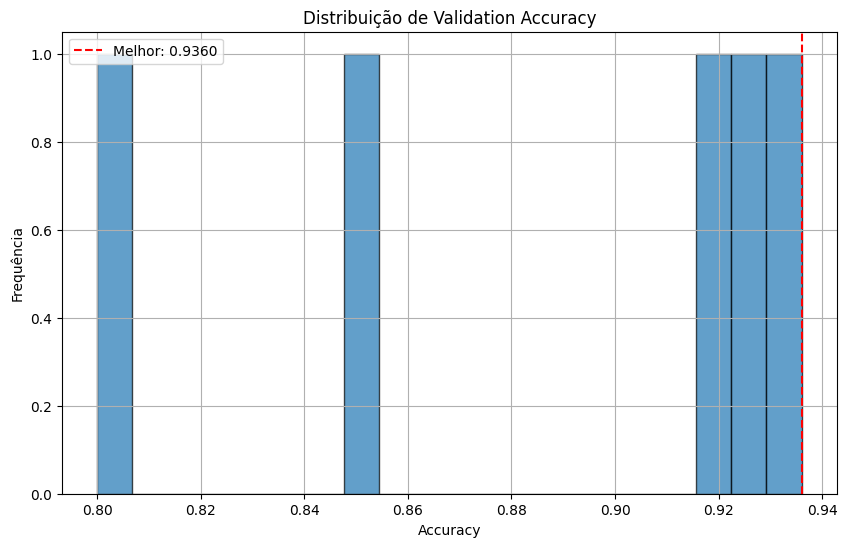


=== Correlações com Accuracy ===
val_acc          1.000000
max_words        0.865893
iteration        0.674121
time             0.489319
batch_size       0.039620
learning_rate   -0.418724
dropout_rate    -0.943100
val_loss        -0.999598
epochs                NaN
weight_decay          NaN
Name: val_acc, dtype: float64


In [13]:
results_df = pd.DataFrame(results)
if 'error' in results_df.columns:
    results_df = results_df[results_df['error'].isna()]

print("=== Melhores Resultados ===")
top_results = results_df.sort_values('val_acc', ascending=False).head(5)
print(top_results[['iteration', 'val_acc', 'val_loss', 'loss_function', 'activation_function', 
                   'learning_rate', 'max_words', 'hidden_neurons']])

plt.figure(figsize=(10, 6))
results_df['val_acc'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribuição de Validation Accuracy')
plt.xlabel('Accuracy')
plt.ylabel('Frequência')
plt.axvline(best_val_acc, color='red', linestyle='--', label=f'Melhor: {best_val_acc:.4f}')
plt.legend()
plt.show()

print("\n=== Correlações com Accuracy ===")
numeric_cols = results_df.select_dtypes(include=[np.number]).columns
if 'val_acc' in numeric_cols:
    correlations = results_df[numeric_cols].corr()['val_acc'].sort_values(ascending=False)
    print(correlations.head(10))

In [14]:
if best_model:
    print(f"Melhor validation accuracy: {best_val_acc:.4f}")
    print(f"Número total de modelos testados: {len(results_df)}")
    print("\nMelhores hiperparâmetros:")
    best_params = results_df.loc[results_df['val_acc'].idxmax()]
    for key, value in best_params.items():
        if key not in ['iteration', 'val_acc', 'val_loss', 'time', 'error']:
            print(f"  {key}: {value}")

Melhor validation accuracy: 0.9360
Número total de modelos testados: 5

Melhores hiperparâmetros:
  loss_function: ('CategoricalCrossEntropy', <class 'src.models_numpy.dnn.losses.CategoricalCrossEntropy'>)
  activation_function: ('LeakyReLU', <class 'src.models_numpy.dnn.activation.LeakyReLUActivation'>)
  vectorizer_type: stylometric
  char_ngram_range: (2, 3)
  max_words: 15000
  hidden_neurons: [256, 128]
  learning_rate: 0.005
  optimizer_type: adam
  epochs: 150
  batch_size: 128
  dropout_rate: 0.2
  weight_decay: 0.0001
  use_batchnorm: True
  patience: 15


## Validação com Dataset Exemplos

=== Validação com Dataset Exemplos ===
Número de amostras de teste: 125
Distribuição de classes:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64

Accuracy no dataset exemplos: 0.2800
Accuracy na validação interna: 0.9360
Diferença: -0.6560

=== Relatório de Classificação (Dataset Exemplos) ===
              precision    recall  f1-score   support

   Anthropic       0.50      0.22      0.30        23
      Google       0.44      0.25      0.32        16
       Human       0.72      0.25      0.37        52
        Meta       0.25      0.06      0.10        17
      OpenAI       0.14      0.71      0.24        17

    accuracy                           0.28       125
   macro avg       0.41      0.30      0.27       125
weighted avg       0.50      0.28      0.30       125



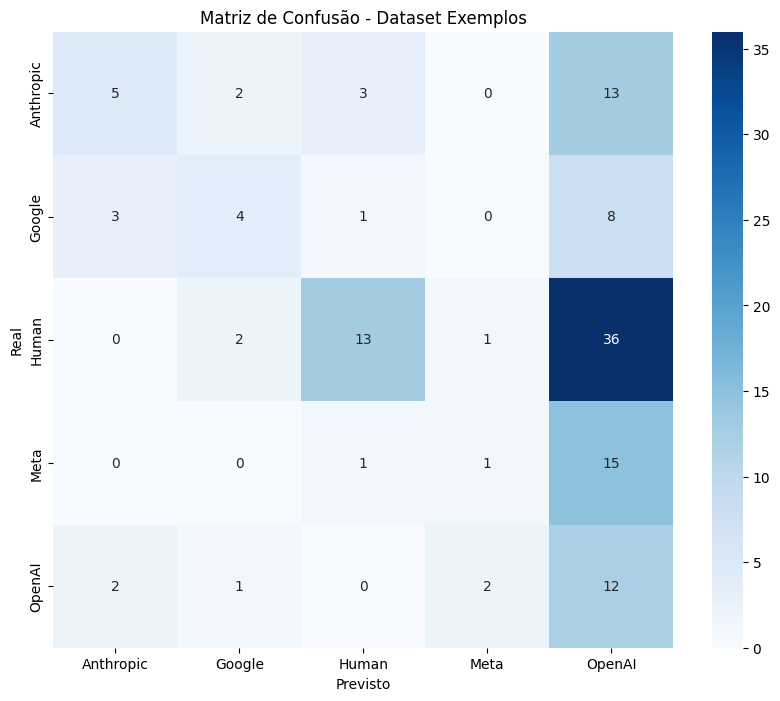

In [15]:
if best_model:
    df_test = pd.read_csv("../data/raw/dataset-exemplos.csv", sep=";")
    
    df_test['label_id'] = df_test['Label'].map(label_map)
    df_test['text_clean'] = df_test['Text'].apply(clean_text)
    
    X_test = best_vectorizer.transform(
        list(df_test['text_clean']),
        list(df_test['Text'])
    )
    class_counts = df['label_id'].value_counts().sort_index().values
    class_weights = len(df) / (num_classes * class_counts)
    class_weights = class_weights / class_weights.sum()
    y_pred_probs = best_model.forward_propagation(X_test, training=False)
    y_pred_weighted = y_pred_probs * class_weights
    y_pred = np.argmax(y_pred_weighted, axis=1)
    y_true = df_test['label_id'].values
    
    print("=== Validação com Dataset Exemplos ===")
    print(f"Número de amostras de teste: {len(df_test)}")
    print(f"Distribuição de classes:\n{df_test['Label'].value_counts()}")
    print()
    
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    
    test_acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy no dataset exemplos: {test_acc:.4f}")
    print(f"Accuracy na validação interna: {best_val_acc:.4f}")
    print(f"Diferença: {test_acc - best_val_acc:.4f}")
    print()
    
    print("=== Relatório de Classificação (Dataset Exemplos) ===")
    print(classification_report(y_true, y_pred, target_names=list(label_map.keys())))
    
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_map.keys(), yticklabels=label_map.keys())
    plt.title('Matriz de Confusão - Dataset Exemplos')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()
else:
    print("Nenhum modelo treinado. Execute as células anteriores primeiro.")

#     # Salvar melhor modelo
#     best_model.save("../saved_models/DNN_best_model.npz")
#     print("\nMelhor modelo salvo em '../saved_models/DNN_best_model.npz'")
    
#     # Salvar também o vectorizer
#     import pickle
#     with open('../saved_models/DNN_best_vectorizer.pkl', 'wb') as f:
#         pickle.dump(best_vectorizer, f)
#     print("Vectorizer salvo em '../saved_models/DNN_best_vectorizer.pkl'")
# else:
#     print("Nenhum modelo treinado com sucesso.")